In [43]:
import scipy.io
from scipy.ndimage import uniform_filter1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [44]:
# Configuration
current_dir = os.getcwd()
data_path = Path(current_dir, "HX3_LHS_finalData_uniformlhs.mat")
models_dir = Path(current_dir, "Models")

# Column names for reference (authoritative list to be confirmed by the Power training script)
col_names = [
    "coolant channel diameter (m)",         # 0
    "HX overall length (m)",                # 1
    "HX overall width (m)",                 # 2
    "Channel height (m)",                   # 3
    "Number of air layers/channels",        # 4
    "Strut Diameter (m)",                   # 5
    "Strut length to diameter ratio",       # 6
    "coolant flow rate (kg/s)",             # 7
    "Air flow rate (kg/s)",                 # 8
    "Area ratio_diff (diffuser exit/inlet)",# 9
    "diffuser half angle (degrees)",        # 10
    "Area ratio_nozz (nozzle inlet/exit)",  # 11
    "nozzle half angle (degrees)",          # 12
    "fan on/off",                           # 13
    "HX weight (kg)",                       # 14
    "HX power (W)",                         # 15
    "Drag (N)",                             # 16
    "Design point (780=Takeoff, 2720=Cruise)", # 17
    "DTAMB (centigrade)",                   # 18
    "T_Bat_in or T_HX_out (centigrade)",    # 19
    "T_HX_in limit (centigrade)",           # 20
    "Heat Load (W)",                        # 21
    "Actual T_HX_in (centigrade)",          # 22
    "porosity",                             # 23
    "air side hydraulic diameter (wrt DP)", # 24
    "HX overall height (m)",                # 25
    "aircraft speed"                        # 26
]

# For Power analysis: ensure outputs are Power and Heat Load (no Drag)
y_indicies = [15, 21]

remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]# Power index and Heat Load index
target_names = [col_names[i] for i in y_indicies]



# Only search for Power model checkpoints (P_MLP_*.pth) to avoid loading D-model files

def load_index_map_from_checkpoint():
    """Try to locate a Power model checkpoint (P_MLP_*.pth) and read an index mapping payload."""
    candidates = []
    candidates += list(Path(current_dir).glob('P_MLP_*.pth'))
    if models_dir.exists():
        candidates += list(models_dir.glob('P_MLP_*.pth'))
    candidates = sorted(set(candidates))
    if not candidates:
        return None
    import torch
    for p in candidates:
        try:
            ck = torch.load(p, map_location='cpu')
        except Exception:
            continue
        # Common keys where index mappings might be stored
        for key in ('index_map','index_mapping','col_index_map','col_indices','indices','index_map_dict','index_map_list'):
            if key in ck:
                return ck[key]
        # sometimes stored under config
        if 'config' in ck and isinstance(ck['config'], dict):
            for key in ('index_map','index_mapping','col_index_map'):
                if key in ck['config']:
                    return ck['config'][key]
        # fallbacks
        if 'y_indices' in ck:
            return {'y_indices': ck['y_indices']}
        if 'remove_cols' in ck:
            return {'remove_cols': ck['remove_cols']}
    return None

index_map = load_index_map_from_checkpoint()
if index_map is not None:
    print('Loaded index_map from checkpoint')
    # Interpret several possible formats for index_map
    if isinstance(index_map, (list, tuple)):
        # If it's a list, assume it's y_indices if length==2 else ignore
        if len(index_map) == 2:
            y_indices = list(index_map)
    elif isinstance(index_map, dict):
        # If dict contains explicit y_indices/remove_cols
        if 'y_indices' in index_map:
            y_indices = list(index_map['y_indices'])
        if 'remove_cols' in index_map:
            remove_cols = list(index_map['remove_cols'])
        # map by common human keys if present
        name_map_keys = {'Power':'HX power (W)','Heat Load':'Heat Load (W)'}
        for short_key, full_name in name_map_keys.items():
            if short_key in index_map and isinstance(index_map[short_key], (int, float)):
                val = int(index_map[short_key])
                if short_key == 'Power' and len(y_indices) >= 1:
                    y_indices[0] = val
                if short_key == 'Heat Load' and len(y_indices) >= 2:
                    y_indices[1] = val

print(f"Data path: {data_path}")
print(f"Target outputs (indices): {y_indicies} => {target_names}")

# Expose remove_cols to other cells (kept here for backwards compatibility)
_default_remove_cols = remove_cols
def get_input_names():
    """Get input parameter names after filtering"""
    remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]
    input_names = [col_names[i] for i in range(len(col_names)) if i not in remove_cols]
    return input_names


Data path: c:\Users\abfat\Desktop\HX3_github\HX3_LHS_finalData_uniformlhs.mat
Target outputs (indices): [15, 21] => ['HX power (W)', 'Heat Load (W)']


In [45]:
def calc_derived_features(input_vector):
    """
    Calculate derived engineering features from input parameters.
    
    Args:
        input_vector: numpy array with columns matching the input_names order
                     Expected indices after removal of remove_cols:
                     0: coolant_channel_diameter
                     1: HX_overall_length
                     2: HX_overall_width
                     3: Channel_height
                     4: Number_of_air_layers_channels
                     5: Strut_Diameter
                     6: Strut_length_to_diameter_ratio
                     (and others...)
    
    Returns:
        dict with keys: 'porosity', 'AS_hyd_diam', 'HX_overall_height', 'frontal_area'
    """
    # Extract parameters (indices match the order after remove_cols filtering)
    coolant_channel_diameter = input_vector[0]
    HX_overall_length = input_vector[1]
    HX_overall_width = input_vector[2]
    Channel_height = input_vector[3]
    num_air_layers = input_vector[4]
    Strut_Diameter = input_vector[5]
    Strut_length_to_diameter_ratio = input_vector[6]
    
    # Calculate HX overall height
    hx_overall_height = ((coolant_channel_diameter + 0.003) * (num_air_layers - 1)) + (Channel_height * num_air_layers)
    
    # Calculate channel volume
    channel_volume = HX_overall_length * HX_overall_width * Channel_height
    
    # Calculate unit cell properties
    unit_cell_solid_volume = 0.75 * np.pi * Strut_Diameter**3 * (Strut_length_to_diameter_ratio + 0.667 - 1.25)
    unit_cell_volume = (Strut_length_to_diameter_ratio * Strut_Diameter)**3
    num_unit_cells_per_channel = channel_volume / unit_cell_volume
    
    # Calculate total solid volume and flow volume
    total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
    flow_volume = (channel_volume * num_air_layers) - total_solid_volume
    
    # Calculate porosity
    porosity = flow_volume / (channel_volume * num_air_layers)
    
    # Calculate A_HT (heat transfer area)
    A_HT = 3 * np.pi * Strut_Diameter**2 * (Strut_length_to_diameter_ratio + (2/np.pi) - 1.5) * num_unit_cells_per_channel * num_air_layers
    
    # Calculate air side hydraulic diameter (dh_p)
    AS_hyd_diam = 4 * porosity * channel_volume * num_air_layers / A_HT
    
    # Calculate frontal area
    frontal_area = HX_overall_width * hx_overall_height
    
    return {
        'porosity': porosity,
        'AS_hyd_diam': AS_hyd_diam,
        'HX_overall_height': hx_overall_height,
        'frontal_area': frontal_area
    }


In [46]:
def load_and_preprocess_data():
    """Load and preprocess data exactly as in the Power training script"""
    # Load data
    data = scipy.io.loadmat(data_path)
    variable_data = data['HXdata']
    print(f"Original data shape: {variable_data.shape}")
    
    # Remove first 2 columns (same as training script)
    variable_data = variable_data[:, 2:]
    
    # Apply same filters as training script
    power_too_high = variable_data[:,15] >= 15000
    weight_too_low = variable_data[:,14] <= 0
    drag_too_low = variable_data[:,16] < -1500
    
    variable_data = variable_data[~power_too_high & ~weight_too_low & ~drag_too_low]
    print(f"Removed {np.sum(power_too_high | weight_too_low | drag_too_low)} rows based on weight/power/drag criteria")
    
    # Remove no diffuser cases
    fan_off = variable_data[:, 13] == 0
    variable_data = variable_data[~fan_off]
    print(f"num of fan-off rows removed (keeping fan-on): {np.sum(fan_off)}")
    print(variable_data[:,13])
    no_div = variable_data[:, 27] == 0
    variable_data = variable_data[~no_div]
    print(f"Removed {np.sum(no_div)} no-diffuser rows")
    
    # Extract inputs and outputs (same as Power training script)
    remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]
    x = np.delete(variable_data, remove_cols, axis=1)
    y = variable_data[:, y_indicies]
    
    print(f"Final data shape - Inputs: {x.shape}, Outputs: {y.shape}")
    
    return x, y, variable_data

# Load the data
X_data, y_data, full_data = load_and_preprocess_data()

Original data shape: (149999, 30)
Removed 6593 rows based on weight/power/drag criteria
num of fan-off rows removed (keeping fan-on): 70345
[1. 1. 1. ... 1. 1. 1.]
Removed 0 no-diffuser rows
Final data shape - Inputs: (73061, 16), Outputs: (73061, 2)


In [47]:
from models import get_device, TaperedMultiLayerNN

def load_model(model_path):
    """Load a trained model with all its components"""
    device = get_device()
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    input_size = X_data.shape[1]
    output_size = len(y_indicies)
    
    # Recreate model
    model = TaperedMultiLayerNN(
        input_size=input_size,
        initial_hidden_size=config['hidden_size'],
        output_size=output_size,
        num_layers=config['layers'],
        dropout=0.10
    ).to(device)
    
    # Load state
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Get scalers
    input_scaler = checkpoint['input_scaler']
    output_scaler = checkpoint['output_scaler']
    
    return model, input_scaler, output_scaler, checkpoint

def find_available_models():
    """Find all available Power models"""
    model_files = []
    
    # Check current directory
    for file in Path(current_dir).glob("P_MLP_*.pth"):
        model_files.append(file)
    
    # Check Models directory if it exists
    if models_dir.exists():
        for file in models_dir.glob("P_MLP_*.pth"):
            model_files.append(file)
    
    return sorted(model_files)

# Find available models
available_models = find_available_models()
print(f"Found {len(available_models)} Power models:")
for i, model_path in enumerate(available_models):
    print(f"  {i}: {model_path.name}")

Found 6 Power models:
  0: P_MLP_1024_2.pth
  1: P_MLP_2048_2.pth
  2: P_MLP_3072_3.pth
  3: P_MLP_4096_3.pth
  4: P_MLP_5120_4.pth
  5: P_MLP_6144_4.pth


In [48]:
def evaluate_model(model, input_scaler, output_scaler, X_test, y_test):
    """Evaluate model performance"""
    device = get_device()
    
    # Prepare data
    X_scaled = torch.tensor(input_scaler.transform(X_test), dtype=torch.float32).to(device)
    
    # Predict
    with torch.no_grad():
        y_pred_scaled = model(X_scaled).cpu().numpy()
    
    # Inverse transform predictions
    y_pred = output_scaler.inverse_transform(y_pred_scaled)
    
    # Calculate metrics for each output
    metrics = {}
    for i, target_name in enumerate(target_names):
        r2 = r2_score(y_test[:, i], y_pred[:, i])
        mse = mean_squared_error(y_test[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
        
        metrics[target_name] = {
            'R2': r2,
            'MSE': mse,
            'MAE': mae,
            'RMSE': np.sqrt(mse)
        }
    
    return y_pred, metrics

def compare_models():
    """Compare all available models"""
    if not available_models:
        print("No models found!")
        return None
    
    # Split data for evaluation (same as training)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, shuffle=True
    )
    
    results = {}
    
    for model_path in available_models:
        try:
            print(f"\nEvaluating {model_path.name}...")
            model, input_scaler, output_scaler, checkpoint = load_model(model_path)
            
            # Evaluate on test set
            y_pred, metrics = evaluate_model(model, input_scaler, output_scaler, X_test, y_test)
            
            results[model_path.name] = {
                'model': model,
                'input_scaler': input_scaler,
                'output_scaler': output_scaler,
                'checkpoint': checkpoint,
                'metrics': metrics,
                'predictions': y_pred,
                'test_data': (X_test, y_test),
            }
            
            # Print metrics
            for target_name, target_metrics in metrics.items():
                print(f"  {target_name}:")
                for metric_name, value in target_metrics.items():
                    print(f"    {metric_name}: {value:.4f}")
                    
        except Exception as e:
            print(f"  Error loading {model_path.name}: {e}")
    
    return results

# Compare all models
model_results = compare_models()


Evaluating P_MLP_1024_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX power (W):
    R2: 0.9907
    MSE: 55908.5808
    MAE: 93.4791
    RMSE: 236.4500
  Heat Load (W):
    R2: 0.9812
    MSE: 4975342.4661
    MAE: 1076.8486
    RMSE: 2230.5476

Evaluating P_MLP_2048_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX power (W):
    R2: 0.9910
    MSE: 54474.8092
    MAE: 92.1108
    RMSE: 233.3984
  Heat Load (W):
    R2: 0.9814
    MSE: 4919718.6139
    MAE: 1076.1374
    RMSE: 2218.0439

Evaluating P_MLP_3072_3.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX power (W):
    R2: 0.9942
    MSE: 34853.1464
    MAE: 71.1099
    RMSE: 186.6900
  Heat Load (W):
    R2: 0.9870
    MSE: 3449464.0752
    MAE: 868.3570
    RMSE: 1857.2733

Evaluating P_MLP_4096_3.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX power (W):
    R2: 0.9943
    MSE: 34572.2561
    MAE: 70.0021
    RMSE: 185.9362
  Heat Load (W


Model Comparison Summary:
------------------------------------------------------------
P_MLP_1024_2.pth: Avg R2 = 0.9859
P_MLP_2048_2.pth: Avg R2 = 0.9862
P_MLP_3072_3.pth: Avg R2 = 0.9906
P_MLP_4096_3.pth: Avg R2 = 0.9905
P_MLP_5120_4.pth: Avg R2 = 0.9931
P_MLP_6144_4.pth: Avg R2 = 0.9931

Best model: P_MLP_6144_4.pth (Avg R2: 0.9931)


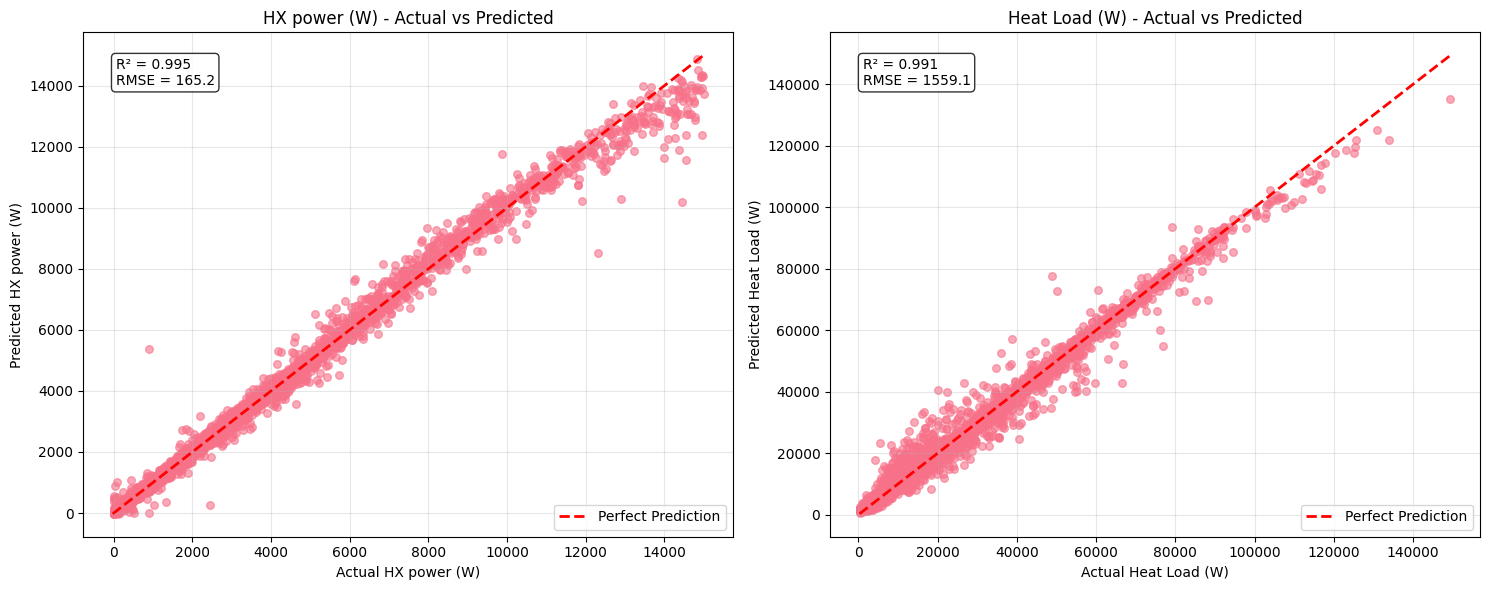

In [49]:
def select_best_model(results):
    """Select best model based on average R2 score"""
    if not results:
        return None, None
    
    best_score = -1
    best_name = None
    
    print("\nModel Comparison Summary:")
    print("-" * 60)
    
    for name, result in results.items():
        # Calculate average R2
        #print(name,result)
        r2_scores = [metrics['R2'] for metrics in result['metrics'].values()]
        avg_r2 = np.mean(r2_scores)
        
        print(f"{name}: Avg R2 = {avg_r2:.4f}")
        
        if avg_r2 > best_score:
            best_score = avg_r2
            best_name = name
    
    print(f"\nBest model: {best_name} (Avg R2: {best_score:.4f})")
    return best_name, results[best_name] if best_name else None

def plot_actual_vs_predicted(best_result, save_plots=False):
    """Create actual vs predicted plots for the best model"""
    if not best_result:
        print("No model results available!")
        return
    
    X_test, y_test = best_result['test_data']
    y_pred = best_result['predictions']
    metrics = best_result['metrics']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for i, (target_name, ax) in enumerate(zip(target_names, axes)):
        # Plot actual vs predicted
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=30)
        
        # Perfect prediction line
        min_val = min(y_test[:, i].min(), y_pred[:, i].min())
        max_val = max(y_test[:, i].max(), y_pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics to plot
        r2 = metrics[target_name]['R2']
        rmse = metrics[target_name]['RMSE']
        ax.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.1f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(f'Actual {target_name}')
        ax.set_ylabel(f'Predicted {target_name}')
        ax.set_title(f'{target_name} - Actual vs Predicted')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('power_model_validation.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Select best model and create validation plots
best_model_name, best_result = select_best_model(model_results)
if best_result:
    plot_actual_vs_predicted(best_result)

Creating parameter sweeps for Power...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU 

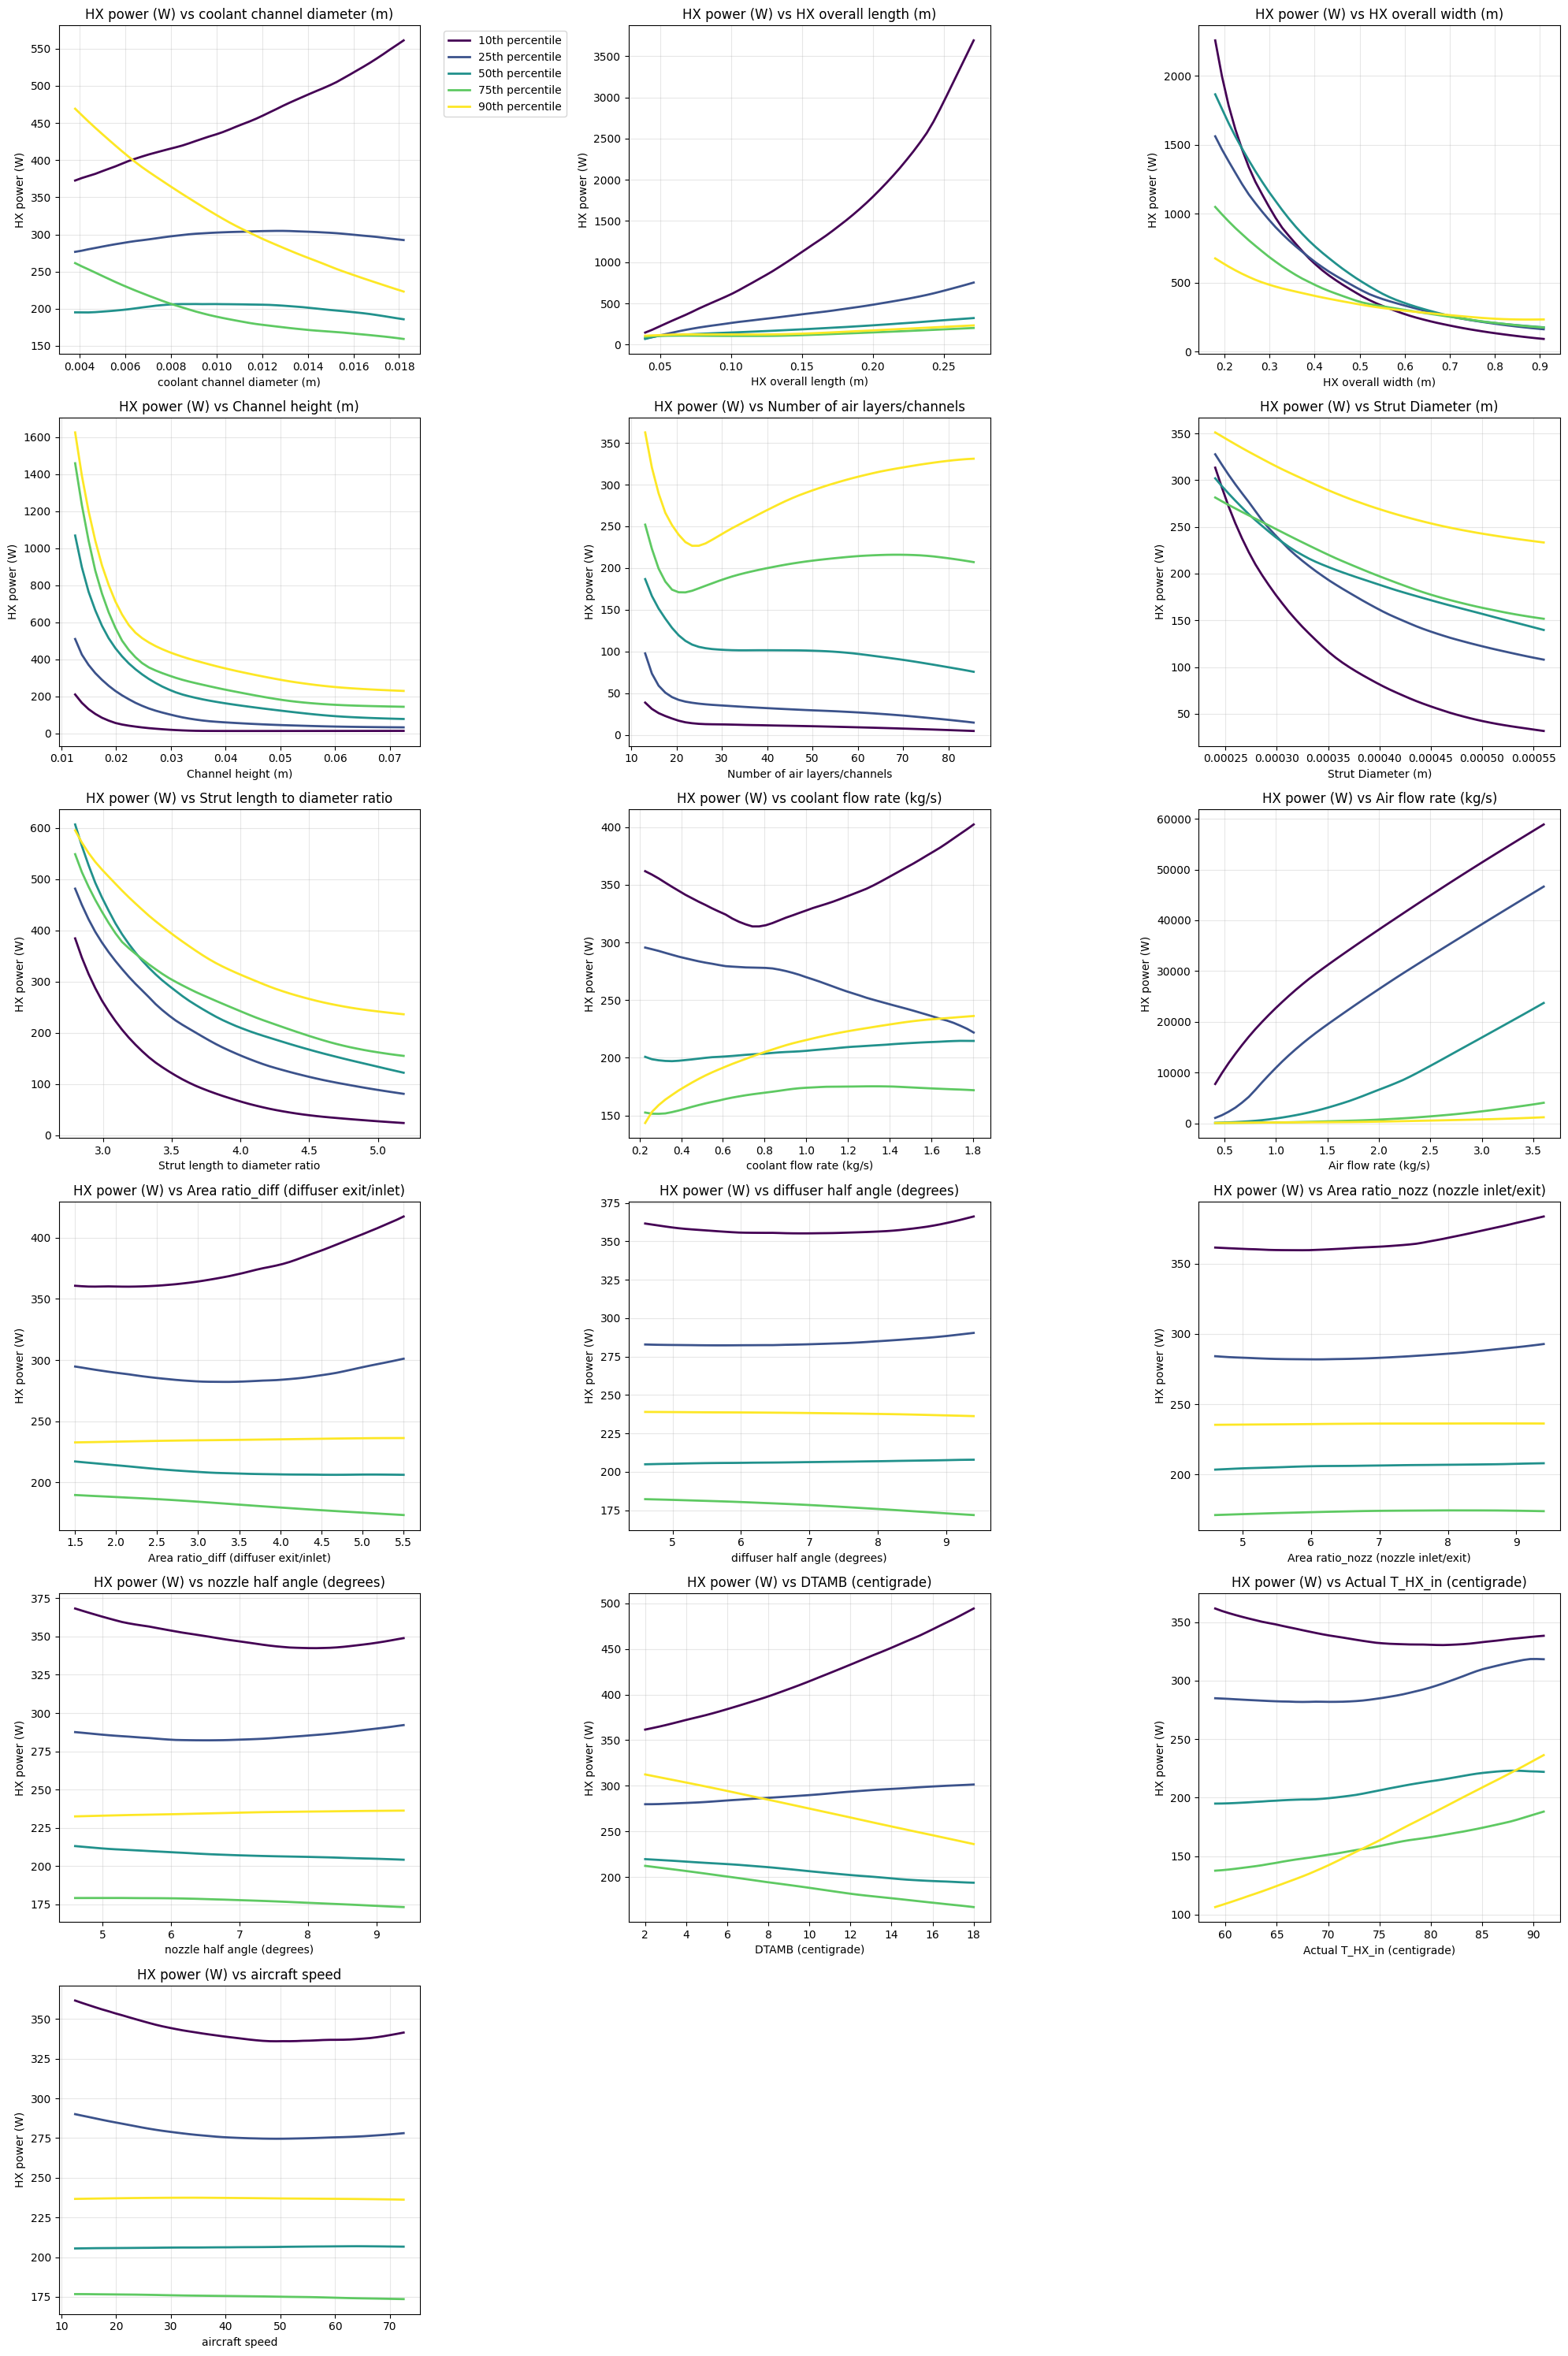

In [50]:

def create_baseline_percentiles(X_data, percentiles=[10, 25, 50, 75, 90]):
    """Create baseline values at different percentiles"""
    baselines = {}
    for p in percentiles:
        baselines[f'{p}th percentile'] = np.percentile(X_data, p, axis=0)
    return baselines

def sweep_parameter(model, input_scaler, output_scaler, X_baseline, param_idx, 
                   param_range, param_name, target_idx=0, n_points=50):
    """Sweep a single parameter while keeping others at baseline"""
    device = get_device()
    
    # Create parameter sweep
    param_values = np.linspace(param_range[0], param_range[1], n_points)
    predictions = []
    
    for param_val in param_values:
        # Create input with swept parameter
        X_sweep = X_baseline.copy()
        X_sweep[param_idx] = param_val
        
        # Predict
        X_scaled = torch.tensor(input_scaler.transform(X_sweep.reshape(1, -1)), 
                               dtype=torch.float32).to(device)
        
        with torch.no_grad():
            y_pred_scaled = model(X_scaled).cpu().numpy()
        
        # Inverse transform
        y_pred = output_scaler.inverse_transform(y_pred_scaled)
        predictions.append(y_pred[0, target_idx])
    
    return param_values, np.array(predictions)

def plot_parameter_sweeps(best_result, target_idx=0, save_plots=False):
    """Plot parameter sweeps for all inputs at different percentiles"""
    if not best_result:
        print("No model results available!")
        return
    
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']
    
    input_names = get_input_names()
    target_name = target_names[target_idx]
    
    # Create baselines at different percentiles
    percentiles = [10, 25, 50, 75, 90]
    baselines = create_baseline_percentiles(X_data, percentiles)
    
    # Calculate number of subplots needed
    n_params = len(input_names)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    
    for i, param_name in enumerate(input_names):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        # Get parameter range (expand by 20% around data range)
        param_min = X_data[:, i].min()
        param_max = X_data[:, i].max()
        param_range = [param_min + 0.1*(param_max-param_min), 
                      param_max - 0.1*(param_max-param_min)]
        
        # Plot sweeps for each percentile baseline
        for p_idx, (percentile_name, baseline) in enumerate(baselines.items()):
            param_vals, predictions = sweep_parameter(
                model, input_scaler, output_scaler, baseline, i, 
                param_range, param_name, target_idx
            )
            
            ax.plot(param_vals, predictions, 
                   color=colors[p_idx], label=percentile_name, linewidth=2)
        
        ax.set_xlabel(param_name)
        ax.set_ylabel(target_name)
        ax.set_title(f'{target_name} vs {param_name}')
        ax.grid(True, alpha=0.3)
        if i == 0:  # Only add legend to first subplot
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Remove empty subplots
    for i in range(n_params, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'{target_name.lower().replace(" ", "_")}_parameter_sweeps.png', 
                   dpi=300, bbox_inches='tight')
    
    plt.show()

# Create parameter sweeps for Power
if best_result:
    print("Creating parameter sweeps for Power...")
    plot_parameter_sweeps(best_result, target_idx=0)  # Power

Creating parameter sweeps for Heat Load...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.


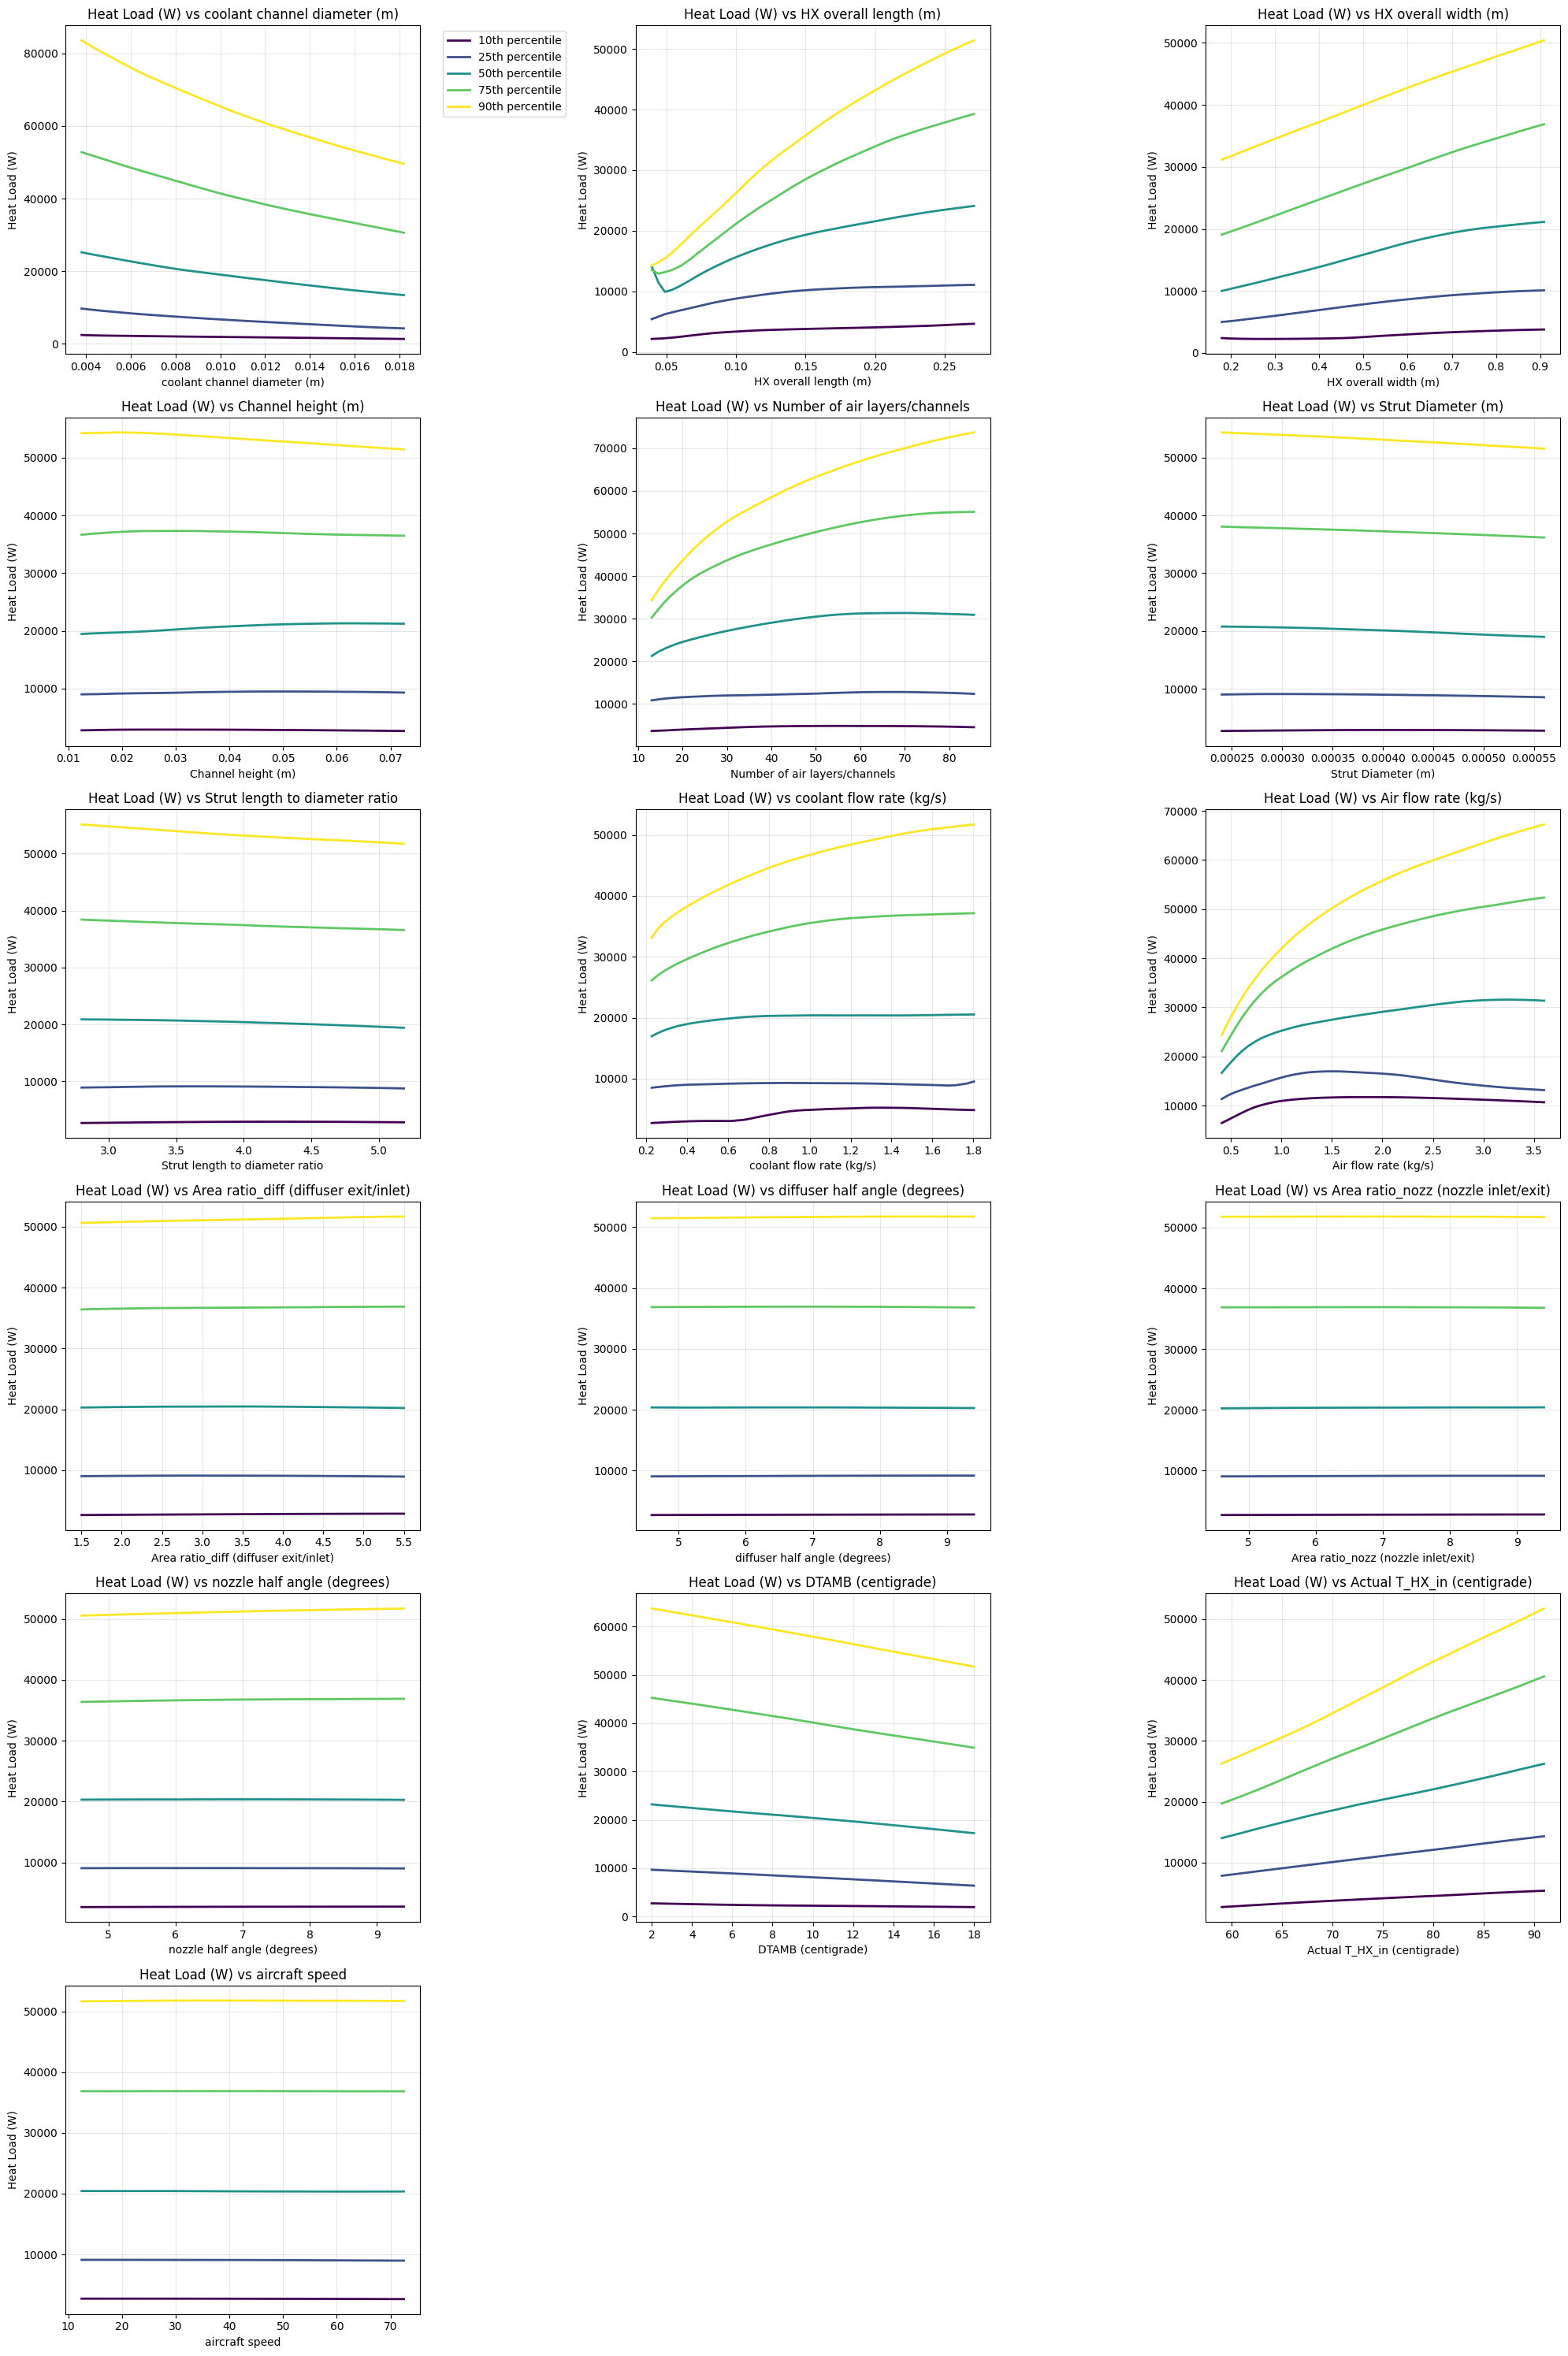

In [51]:
# Create parameter sweeps for Heat Load
if best_result:
    print("Creating parameter sweeps for Heat Load...")
    plot_parameter_sweeps(best_result, target_idx=1)  # Heat Load

\n============================================================
TRAINING HISTORY ANALYSIS


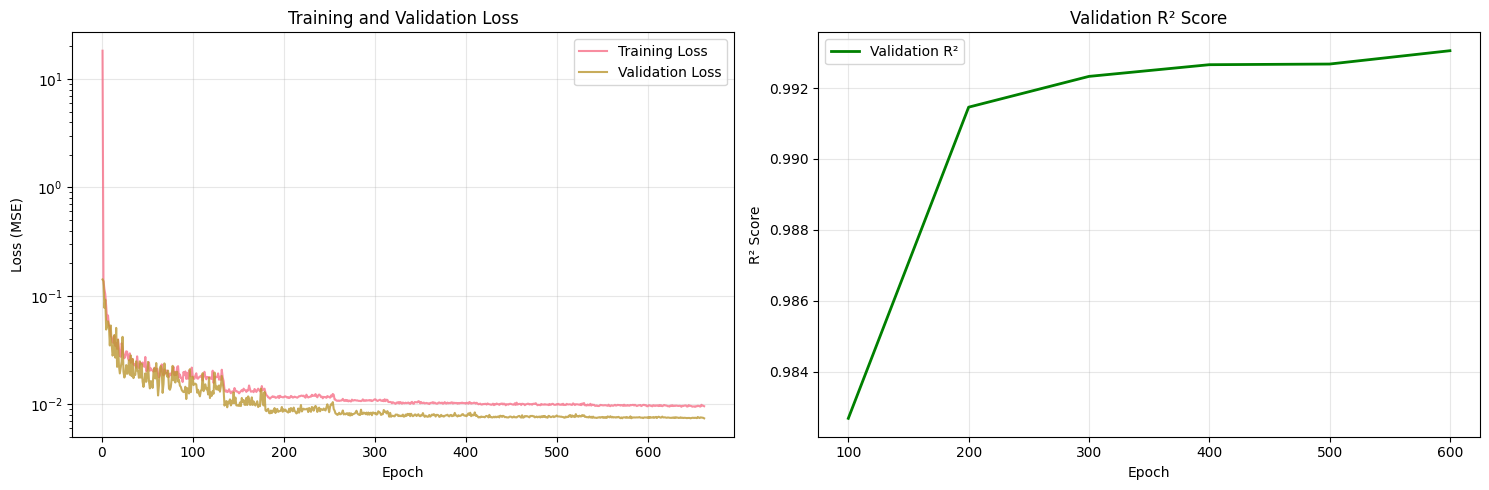

Final Training Loss: 0.009556
Final Validation Loss: 0.007384
Final Validation R²: 0.9931
Best Validation Loss: 0.007383826363366097
Best Validation R²: 0.9930538535118103
Training stopped at epoch: 661
\n================================================================================
POWER MODEL ANALYSIS SUMMARY
\nBest Model: P_MLP_6144_4.pth
Architecture: 6144 hidden units, 4 layers
Loss Function: MSE
Batch Size: 2048
\nModel Performance:
\nHX power (W):
  R2: 0.9955
  MSE: 27291.9481
  MAE: 60.4306
  RMSE: 165.2027
\nHeat Load (W):
  R2: 0.9908
  MSE: 2430689.2631
  MAE: 709.4426
  RMSE: 1559.0668
\nData Information:
Total samples: 73061
Input features: 16
Output targets: 2
\nInput Feature Ranges:
  coolant channel diameter (m): [0.0020, 0.0200]
  HX overall length (m): [0.0105, 0.3000]
  HX overall width (m): [0.0880, 1.0000]
  Channel height (m): [0.0050, 0.0800]
  Number of air layers/channels: [4.0002, 94.6528]
  Strut Diameter (m): [0.0002, 0.0006]
  Strut length to diameter ra

In [52]:
def plot_training_history(best_result):
    """Plot training history of the best model"""
    if not best_result or 'checkpoint' not in best_result:
        print("No training history available!")
        return
    
    checkpoint = best_result['checkpoint']
    
    # Extract training history
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    val_r2_history = checkpoint.get('val_r2_history', [])
    
    if not train_losses:
        print("No training history found in checkpoint!")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss history
    epochs = range(1, len(train_losses) + 1)
    axes[0].plot(epochs, train_losses, label='Training Loss', alpha=0.8)
    axes[0].plot(epochs, val_losses, label='Validation Loss', alpha=0.8)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')
    
    # R2 history (if available)
    if val_r2_history:
        # R2 is computed every N epochs, so create appropriate x-axis
        r2_epochs = range(100, len(val_r2_history)*100 + 1, 100)  # Assuming every 100 epochs
        axes[1].plot(r2_epochs, val_r2_history, 'g-', label='Validation R²', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('R² Score')
        axes[1].set_title('Validation R² Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No R² history available', 
                    transform=axes[1].transAxes, ha='center', va='center')
        axes[1].set_title('R² History Not Available')
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print(f"Final Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Validation Loss: {val_losses[-1]:.6f}")
    if val_r2_history:
        print(f"Final Validation R²: {val_r2_history[-1]:.4f}")
    print(f"Best Validation Loss: {checkpoint.get('best_val_loss', 'N/A')}")
    print(f"Best Validation R²: {checkpoint.get('best_val_r2', 'N/A')}")
    print(f"Training stopped at epoch: {checkpoint.get('epoch', 'N/A')}")

def print_analysis_summary(best_result):
    """Print comprehensive analysis summary"""
    print("\\n" + "="*80)
    print("POWER MODEL ANALYSIS SUMMARY")
    print("="*80)
    
    if not best_result:
        print("No model results available!")
        return
    
    # Model info
    config = best_result['checkpoint']['config']
    print(f"\\nBest Model: {best_model_name}")
    print(f"Architecture: {config['hidden_size']} hidden units, {config['layers']} layers")
    print(f"Loss Function: {config['loss']}")
    print(f"Batch Size: {config['batch_size']}")
    
    # Performance metrics
    print(f"\\nModel Performance:")
    metrics = best_result['metrics']
    for target_name, target_metrics in metrics.items():
        print(f"\\n{target_name}:")
        for metric_name, value in target_metrics.items():
            print(f"  {metric_name}: {value:.4f}")
    
    # Data info
    print(f"\\nData Information:")
    print(f"Total samples: {len(X_data)}")
    print(f"Input features: {len(get_input_names())}")
    print(f"Output targets: {len(target_names)}")
    
    # Feature ranges
    print(f"\\nInput Feature Ranges:")
    input_names = get_input_names()
    for i, name in enumerate(input_names):
        min_val = X_data[:, i].min()
        max_val = X_data[:, i].max()
        print(f"  {name}: [{min_val:.4f}, {max_val:.4f}]")
    
    print(f"\\nOutput Target Ranges:")
    for i, name in enumerate(target_names):
        min_val = y_data[:, i].min()
        max_val = y_data[:, i].max()
        print(f"  {name}: [{min_val:.2f}, {max_val:.2f}]")

# Plot training history and print summary
if best_result:
    print("\\n" + "="*60)
    print("TRAINING HISTORY ANALYSIS")
    print("="*60)
    plot_training_history(best_result)
    
    print_analysis_summary(best_result)

In [53]:
# Iso-Heat-Load sweeps with adjustable features (v2) — Power (extended with optional conditioning)
import numpy as np
import torch
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

def plot_iso_heatload_sweeps_v2(
    best_result,
    heat_load_percentiles=(25, 50, 75),
    n_points_per_feature=35,
    baseline='median',                   # 'median' | 'p25' | 'p75' | 'match'
    tol_rel=0.02,                        # relative HL tolerance (e.g., 0.02 = ±2%)
    max_iters=30,                        # projection iterations (base)
    clamp_percentiles=(5, 95),           # dataset band (scaled z-space)
    features=None,                       # features to sweep (indices). None = all
    adjustable_features='all',           # 'all' | list[int] | list[str] (names) -> dims allowed to move
    smooth_window=5,
    share_y=False,                       # default to per-axes y-limits to avoid empty space
    save_plots=False,
    trust_radius=None,                   # trust window (scaled units) around warm-start for adjustable dims
    trust_mode='fixed',                  # 'fixed' | 'none'
    lock_swept_feature=True,             # remove swept feature from adjustable mask so it stays exactly on grid
    deterministic=True,                  # re-project each grid point from warm-start (no chaining drift)
    raw_unit_grid=False,                 # build uniform raw-unit grid then map to z (else uniform z grid)
    feature_values_override=None,        # dict {feat_idx: np.array(raw_values)} for explicit grids
    # ---- NEW OPTIONAL CONDITIONING ARGUMENTS (defaults preserve legacy behavior) ----
    use_scaled_residual=False,           # if True, solve HL constraint in scaled output space for conditioning
    adaptive_warmstart_features=None,    # list of feature indices to chain projections even if deterministic=True
    high_sensitivity_iter_boost=120,     # iteration cap for features in adaptive_warmstart_features
    residual_damping=False,              # enable residual-based step damping (for high-sensitivity locked features)
    length_idx_hint=1,                   # convenience default: index of HX overall length
    skip_warm_start_projection=False,    # if True, skip initial projection of baseline to target HL (for testing)
    # ---- NEW STABILITY CONTROLS ----
    lock_feature_names=None,             # list[str]: features to FORCE lock (never adjustable), by input name
    max_step=0.3,                        # max step size in z for a single projection iteration
    line_search=True,                    # enable simple backtracking line search on residual
    ls_max_steps=6,                      # backtracking steps
):
    """
    Iso-Heat-Load (HL constant) sweeps for the Power model.
    New stability controls:
      - lock_feature_names: explicitly disallow certain inputs (e.g., operating conditions) from adjusting.
      - max_step: tighter cap on z-step per iteration.
      - line_search: backtrack if residual doesn't improve after a step.
    """
    if not best_result:
        print("No model results available!")
        return

    device = get_device()
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']

    input_names = get_input_names()
    n_features = len(input_names)

    if features is None:
        features = list(range(n_features))

    # Resolve adjustable set
    if adjustable_features == 'all':
        base_adjustable = set(range(n_features))
    else:
        if isinstance(adjustable_features, (list, tuple)):
            if all(isinstance(a, int) for a in adjustable_features):
                base_adjustable = set(int(a) for a in adjustable_features)
            elif all(isinstance(a, str) for a in adjustable_features):
                name_to_idx = {name: i for i, name in enumerate(input_names)}
                missing = [a for a in adjustable_features if a not in name_to_idx]
                if missing:
                    raise ValueError(f"Unknown feature names in adjustable_features: {missing}")
                base_adjustable = {name_to_idx[a] for a in adjustable_features}
            else:
                raise ValueError("adjustable_features must be 'all', list[int], or list[str]")
        else:
            raise ValueError("adjustable_features must be 'all', list[int], or list[str]")

    # Force-lock specific features by name (e.g., operating conditions)
    if lock_feature_names:
        name_to_idx = {name: i for i, name in enumerate(input_names)}
        for nm in lock_feature_names:
            if nm in name_to_idx and name_to_idx[nm] in base_adjustable:
                base_adjustable.remove(name_to_idx[nm])

    # Default sensitive list empty unless provided
    if adaptive_warmstart_features is None:
        adaptive_warmstart_features = []

    # Scaler tensors
    x_mean = torch.tensor(input_scaler.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(input_scaler.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(output_scaler.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(output_scaler.scale_, dtype=torch.float32, device=device)

    # Dataset band
    Z_data = (torch.tensor(X_data, dtype=torch.float32) - x_mean.cpu()) / x_scale.cpu()
    z_low = torch.tensor(np.percentile(Z_data.numpy(), clamp_percentiles[0], axis=0), dtype=torch.float32, device=device)
    z_high = torch.tensor(np.percentile(Z_data.numpy(), clamp_percentiles[1], axis=0), dtype=torch.float32, device=device)

    target_heat_loads = [float(np.percentile(y_data[:, 1], p)) for p in heat_load_percentiles]

    def predict_y_real_from_z(z_row):
        with torch.no_grad():
            y_scaled = model(z_row.unsqueeze(0))
        return y_scaled[0] * y_scale + y_mean  # [Power, HL]

    def g_heatload(z_row, target_hl):
        z_row = z_row.unsqueeze(0).clone().detach().requires_grad_(True)
        y_scaled = model(z_row)
        if use_scaled_residual:
            hl_scaled = y_scaled[0, 1]
            target_scaled = (target_hl - y_mean[1].item()) / y_scale[1].item()
            g = hl_scaled - target_scaled
        else:
            y_real = y_scaled * y_scale + y_mean
            g = y_real[0, 1] - target_hl
        return g, z_row

    def project_to_iso_hl(z_init, fixed_idx, fixed_z_value, target_hl, tol_abs, max_iters_local, adjustable_mask, trust_low=None, trust_high=None):
        z = z_init.clone().detach()
        z[fixed_idx] = fixed_z_value
        for _ in range(max_iters_local):
            g, z_autograd = g_heatload(z, torch.tensor(target_hl, dtype=torch.float32, device=device))
            g_val = float(g.item())
            if abs(g_val) <= tol_abs:
                break
            grad = torch.autograd.grad(g, z_autograd, retain_graph=False, create_graph=False)[0][0]
            mask = adjustable_mask.clone()
            mask[fixed_idx] = False  # never adjust the fixed coordinate
            grad_adj = grad[mask]
            denom = float((grad_adj.norm() ** 2).item())
            if denom < 1e-12:
                break
            step_scale = -g_val / (denom + 1e-12)

            if residual_damping:
                shrink = min(1.0, (tol_abs * 5.0) / (abs(g_val) + 1e-12))
                step_scale *= shrink

            delta_adj = step_scale * grad_adj
            # clip step
            cap = float(max_step)
            if residual_damping:
                # dynamic cap scaled by residual
                cap = max_step * max(0.2, min(1.0, (tol_abs * 10.0) / (abs(g_val) + 1e-9)))
            step_norm = float(delta_adj.norm().item())
            if step_norm > cap:
                delta_adj = delta_adj * (cap / (step_norm + 1e-12))

            # Backtracking line search if residual does not improve
            z_new = z.clone()
            z_new[mask] = z_new[mask] + delta_adj
            z_new[fixed_idx] = fixed_z_value

            low = z_low
            high = z_high
            if trust_low is not None:
                low = torch.maximum(low, trust_low)
            if trust_high is not None:
                high = torch.minimum(high, trust_high)
            z_new[mask] = torch.max(torch.min(z_new[mask], high[mask]), low[mask])

            if line_search:
                tried = 0
                while tried < ls_max_steps:
                    g_new, _ = g_heatload(z_new, torch.tensor(target_hl, dtype=torch.float32, device=device))
                    if abs(float(g_new.item())) <= abs(g_val) * 0.99:
                        break
                    # shrink step
                    delta_adj *= 0.5
                    z_new = z.clone()
                    z_new[mask] = z_new[mask] + delta_adj
                    z_new[fixed_idx] = fixed_z_value
                    z_new[mask] = torch.max(torch.min(z_new[mask], high[mask]), low[mask])
                    tried += 1

            z = z_new
        return z

    # Layout
    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 6 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    colors = plt.cm.viridis(np.linspace(0, 1, len(target_heat_loads)))
    global_min_y, global_max_y = np.inf, -np.inf
    legend_handles, legend_labels = [], []

    # --- Collect sweep data for external plotting ---
    sweep_data = {}

    for idx_plot, feat_idx in enumerate(features):
        row = idx_plot // n_cols
        col = idx_plot % n_cols
        ax = axes[row, col]

        adjustable_mask = torch.zeros(n_features, dtype=torch.bool, device=device)
        for i in base_adjustable:
            adjustable_mask[i] = True
        if lock_swept_feature:
            adjustable_mask[feat_idx] = False
        else:
            adjustable_mask[feat_idx] = True

        feat_sensitive = feat_idx in adaptive_warmstart_features
        local_max_iters = high_sensitivity_iter_boost if feat_sensitive else max_iters
        chain_mode = (not deterministic) or feat_sensitive

        # Build sweep grid
        if feature_values_override and feat_idx in feature_values_override:
            raw_vals = np.array(feature_values_override[feat_idx], dtype=float)
            z_fixed_vals = torch.tensor((raw_vals - x_mean[feat_idx].item())/x_scale[feat_idx].item(), dtype=torch.float32, device=device)
        else:
            if raw_unit_grid:
                raw_min = float((z_low[feat_idx]*x_scale[feat_idx] + x_mean[feat_idx]).item())
                raw_max = float((z_high[feat_idx]*x_scale[feat_idx] + x_mean[feat_idx]).item())
                raw_vals = np.linspace(raw_min, raw_max, n_points_per_feature)
                z_fixed_vals = torch.tensor((raw_vals - x_mean[feat_idx].item())/x_scale[feat_idx].item(), dtype=torch.float32, device=device)
            else:
                zmin = float(z_low[feat_idx].item())
                zmax = float(z_high[feat_idx].item())
                z_fixed_vals = torch.linspace(zmin, zmax, n_points_per_feature, device=device)

        for color, (p, target_hl) in zip(colors, zip(heat_load_percentiles, target_heat_loads)):
            tol_abs = max(target_hl * tol_rel, 1e-3) if not use_scaled_residual else tol_rel
            if baseline == 'median':
                x_base_np = np.percentile(X_data, 50, axis=0)
            elif baseline == 'p25':
                x_base_np = np.percentile(X_data, 25, axis=0)
            elif baseline == 'p75':
                x_base_np = np.percentile(X_data, 75, axis=0)
            elif baseline == 'match':
                x_base_np = np.percentile(X_data, p, axis=0)
            else:
                x_base_np = np.percentile(X_data, 50, axis=0)

            x_base = torch.tensor(x_base_np, dtype=torch.float32, device=device)
            z_base = (x_base - x_mean) / x_scale
            # Initial projection to target HL at warm-start
            warm_start = project_to_iso_hl(
                z_base.clone(),
                feat_idx,
                z_base[feat_idx],
                target_hl,
                tol_abs,
                local_max_iters,
                adjustable_mask=adjustable_mask,
                trust_low=None,
                trust_high=None,
            )
            if skip_warm_start_projection:
                warm_start = z_base.clone()
                warm_start[feat_idx] = z_base[feat_idx]

            t_low = t_high = None
            if trust_radius is not None and trust_mode == 'fixed':
                t_low = warm_start - float(trust_radius)
                t_high = warm_start + float(trust_radius)

            xs, powers = [], []
            z_curr = warm_start.clone()
            for fixed_z in z_fixed_vals:
                z_start = warm_start.clone() if (deterministic and not chain_mode) else z_curr
                z_proj = project_to_iso_hl(
                    z_start,
                    feat_idx,
                    fixed_z,
                    target_hl,
                    tol_abs,
                    local_max_iters,
                    adjustable_mask=adjustable_mask,
                    trust_low=t_low,
                    trust_high=t_high,
                )
                if chain_mode:
                    z_curr = z_proj.clone()
                y_real = predict_y_real_from_z(z_proj)
                pwr = float(y_real[0].item())  # Power
                x_val = float((fixed_z * x_scale[feat_idx] + x_mean[feat_idx]).item())
                xs.append(x_val)
                powers.append(pwr)

            xs = np.asarray(xs)
            powers = np.asarray(powers)
            if smooth_window and smooth_window > 1 and len(powers) >= smooth_window:
                powers = uniform_filter1d(powers, size=smooth_window, mode='reflect')

            # --- Add to sweep_data ---
            if feat_idx not in sweep_data:
                sweep_data[feat_idx] = {}
            sweep_data[feat_idx][f'p{p}'] = {
                'feature_values': xs,
                'Power': powers,
                'target_heat_load': target_hl,
            }

            ln, = ax.plot(xs, powers, color=color, lw=2.2, alpha=0.9, label=f"{p}th % ({target_hl:.0f}W)")
            ax.scatter(xs, powers, color=color, s=12, alpha=0.5)

            if share_y:
                global_min_y = min(global_min_y, float(powers.min()))
                global_max_y = max(global_max_y, float(powers.max()))
        
        ax.set_xlabel(input_names[feat_idx])
        tags = []
        if lock_swept_feature: tags.append('LOCK')
        if use_scaled_residual: tags.append('scaled')
        if (feat_idx in adaptive_warmstart_features): tags.append('chain')
        tag_str = ', '.join(tags) if tags else 'std'
        ax.set_ylabel('Power (W)')
        ax.set_title(f'Power vs {input_names[feat_idx]} (iso-HL {tag_str})')
        ax.grid(True, alpha=0.3)

    for k in range(len(features), n_rows * n_cols):
        r = k // n_cols
        c = k % n_cols
        fig.delaxes(axes[r, c])

    if share_y and global_min_y < global_max_y:
        pad = 0.05 * (global_max_y - global_min_y)
        ymin = global_min_y - pad
        ymax = global_max_y + pad
        for ax in fig.axes:
            if hasattr(ax, 'set_ylim'):
                ax.set_ylim(ymin, ymax)

    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc='upper center', ncol=len(legend_handles), frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.suptitle(
        f'Iso-Heat-Load Power Sweeps (baseline={baseline}, tol={int(tol_rel*100)}%, lock={lock_swept_feature}, det={deterministic})',
        fontsize=16,
    )

    if save_plots:
        plt.savefig('power_iso_heatload_projection_sweeps_v2.png', dpi=300, bbox_inches='tight')

    plt.show()
    print("Generated iso-Heat-Load sweeps (v2) with stability controls.")

    # --- Return sweep data for external plotting ---
    return {'paths': sweep_data}


In [54]:
input_feature_names = get_input_names()
indices = [0, 1,2,3,4,5,6, 7,8]
inputs_to_vary = [input_feature_names[i] for i in indices]
print(f"Input features to vary: {inputs_to_vary}")

Input features to vary: ['coolant channel diameter (m)', 'HX overall length (m)', 'HX overall width (m)', 'Channel height (m)', 'Number of air layers/channels', 'Strut Diameter (m)', 'Strut length to diameter ratio', 'coolant flow rate (kg/s)', 'Air flow rate (kg/s)']


In [55]:
# ============================================================================
# ROBUST DERIVED FEATURE SWEEPING - Dependency-safe 2D heatmaps (Power/Heat Load)
# ============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MaxNLocator

DERIVED_FEATURES = {'porosity', 'AS_hyd_diam', 'frontal_area'}

def _normalize_feature_name(name):
    if name is None:
        return name
    aliases = {
        'as_hyd_diam': 'AS_hyd_diam',
        'AS hyd diam': 'AS_hyd_diam',
        'airside_hyd_diam': 'AS_hyd_diam',
    }
    return aliases.get(name, name)

def _build_name_maps():
    input_names = get_input_names()
    name_to_idx = {name: i for i, name in enumerate(input_names)}
    return input_names, name_to_idx

def _compute_derived_ranges(X_data, percentile_range=(9, 95)):
    p_lo, p_hi = percentile_range
    all_derived = []
    for row in X_data:
        try:
            all_derived.append(calc_derived_features(row))
        except Exception:
            continue
    ranges = {}
    for feat in DERIVED_FEATURES:
        vals = np.array([d[feat] for d in all_derived], dtype=float)
        ranges[feat] = {
            'min': float(np.percentile(vals, p_lo)),
            'max': float(np.percentile(vals, p_hi)),
            'all': vals,
        }
    return ranges

def _compute_direct_ranges(X_data, name_to_idx, percentile_range=(9, 95)):
    p_lo, p_hi = percentile_range
    direct = {}
    for name, idx in name_to_idx.items():
        direct[name] = {
            'min': float(np.percentile(X_data[:, idx], p_lo)),
            'max': float(np.percentile(X_data[:, idx], p_hi)),
        }
    return direct

def _feature_axis_values(feature_name, grid_size, derived_ranges, direct_ranges):
    if feature_name in derived_ranges:
        lo, hi = derived_ranges[feature_name]['min'], derived_ranges[feature_name]['max']
    elif feature_name in direct_ranges:
        lo, hi = direct_ranges[feature_name]['min'], direct_ranges[feature_name]['max']
    else:
        raise ValueError(f"Unknown feature '{feature_name}'.")
    return np.linspace(lo, hi, grid_size), (lo, hi)

def _derived_control_variable(feature_name):
    controls = {
        'porosity': 'Strut length to diameter ratio',
        'AS_hyd_diam': 'Strut Diameter (m)',
        'frontal_area': 'HX overall width (m)',
    }
    return controls.get(feature_name, None)

def _validate_feature_pair(feature_1_name, feature_2_name):
    f1 = _normalize_feature_name(feature_1_name)
    f2 = _normalize_feature_name(feature_2_name)

    if f1 in DERIVED_FEATURES and f2 not in DERIVED_FEATURES:
        ctrl = _derived_control_variable(f1)
        if ctrl == f2:
            raise ValueError(
                f"Invalid pair: '{f1}' cannot be swept independently against '{f2}' "
                f"because '{f2}' is the control variable used to set '{f1}'."
            )
    if f2 in DERIVED_FEATURES and f1 not in DERIVED_FEATURES:
        ctrl = _derived_control_variable(f2)
        if ctrl == f1:
            raise ValueError(
                f"Invalid pair: '{f2}' cannot be swept independently against '{f1}' "
                f"because '{f1}' is the control variable used to set '{f2}'."
            )

def _set_derived_feature(x, feature_name, target_value, name_to_idx, X_data):
    x_new = x.copy()
    feature_name = _normalize_feature_name(feature_name)

    idx_LD = name_to_idx['Strut length to diameter ratio']
    idx_D = name_to_idx['Strut Diameter (m)']
    idx_W = name_to_idx['HX overall width (m)']
    idx_cd = name_to_idx['coolant channel diameter (m)']
    idx_nal = name_to_idx['Number of air layers/channels']
    idx_ch = name_to_idx['Channel height (m)']

    p5_LD, p95_LD = np.percentile(X_data[:, idx_LD], [5, 95])
    p5_D, p95_D = np.percentile(X_data[:, idx_D], [5, 95])
    p5_W, p95_W = np.percentile(X_data[:, idx_W], [5, 95])
    p5_ch, p95_ch = np.percentile(X_data[:, idx_ch], [5, 95])

    if feature_name == 'porosity':
        lo, hi = p5_LD, p95_LD
        for _ in range(80):
            mid = 0.5 * (lo + hi)
            x_t = x_new.copy()
            x_t[idx_LD] = mid
            val = calc_derived_features(x_t)['porosity']

            x_lo = x_new.copy()
            x_lo[idx_LD] = lo
            val_lo = calc_derived_features(x_lo)['porosity']

            if abs(val - target_value) < 1e-10:
                lo, hi = mid, mid
                break

            increasing = (val > val_lo)
            if increasing:
                if val < target_value:
                    lo = mid
                else:
                    hi = mid
            else:
                if val > target_value:
                    lo = mid
                else:
                    hi = mid

        x_new[idx_LD] = np.clip(0.5 * (lo + hi), p5_LD, p95_LD)

    elif feature_name == 'AS_hyd_diam':
        L_D = x_new[idx_LD]
        porosity = calc_derived_features(x_new)['porosity']
        denom = 4.0 * porosity * (L_D ** 3)
        numer = target_value * 3.0 * np.pi * (L_D + 2.0 / np.pi - 1.5)
        if denom > 1e-14:
            D_raw = numer / denom
            D_clipped = np.clip(D_raw, p5_D, p95_D)
            x_new[idx_D] = D_clipped
            # When D clips, jointly optimise (D, LD) to cover full axis range
            if abs(D_raw - D_clipped) > 1e-12 * max(abs(D_raw), 1e-12):
                _scales = np.array([max(p95_D - p5_D, 1e-12), max(p95_LD - p5_LD, 1e-12)])
                _x0j = np.array([D_clipped, x_new[idx_LD]], dtype=float)
                def _obj_hyd(v, _xb=x_new, _t=target_value):
                    xc = _xb.copy()
                    xc[idx_D] = np.clip(v[0], p5_D, p95_D)
                    xc[idx_LD] = np.clip(v[1], p5_LD, p95_LD)
                    val = calc_derived_features(xc)['AS_hyd_diam']
                    mm = ((val - _t) / max(abs(_t) * 0.02, 1e-9)) ** 2
                    delta = (v - _x0j) / _scales
                    return mm + 0.05 * float(np.dot(delta, delta))
                _res = minimize(_obj_hyd, _x0j,
                                bounds=[(p5_D, p95_D), (p5_LD, p95_LD)],
                                method='L-BFGS-B',
                                options={'maxiter': 120, 'ftol': 1e-12})
                _v = _res.x if _res.success else _x0j
                x_new[idx_D] = float(np.clip(_v[0], p5_D, p95_D))
                x_new[idx_LD] = float(np.clip(_v[1], p5_LD, p95_LD))

    elif feature_name == 'frontal_area':
        hx_height = ((x_new[idx_cd] + 0.003) * (x_new[idx_nal] - 1)) + (x_new[idx_ch] * x_new[idx_nal])
        if hx_height > 1e-12:
            W_raw = target_value / hx_height
            W_clipped = np.clip(W_raw, p5_W, p95_W)
            x_new[idx_W] = W_clipped
            # When W clips, jointly optimise (W, ch) to cover full axis range
            if abs(W_raw - W_clipped) > 1e-12 * max(abs(W_raw), 1e-12):
                _scales = np.array([max(p95_W - p5_W, 1e-12), max(p95_ch - p5_ch, 1e-12)])
                _x0j = np.array([W_clipped, x_new[idx_ch]], dtype=float)
                def _obj_area(v, _xb=x_new, _t=target_value):
                    xc = _xb.copy()
                    xc[idx_W] = np.clip(v[0], p5_W, p95_W)
                    xc[idx_ch] = np.clip(v[1], p5_ch, p95_ch)
                    val = calc_derived_features(xc)['frontal_area']
                    mm = ((val - _t) / max(abs(_t) * 0.02, 1e-9)) ** 2
                    delta = (v - _x0j) / _scales
                    return mm + 0.05 * float(np.dot(delta, delta))
                _res = minimize(_obj_area, _x0j,
                                bounds=[(p5_W, p95_W), (p5_ch, p95_ch)],
                                method='L-BFGS-B',
                                options={'maxiter': 120, 'ftol': 1e-12})
                _v = _res.x if _res.success else _x0j
                x_new[idx_W] = float(np.clip(_v[0], p5_W, p95_W))
                x_new[idx_ch] = float(np.clip(_v[1], p5_ch, p95_ch))

    return x_new

def _is_derived_target_achievable(x, feature_name, target_value, rel_tol=0.02, abs_tol=1e-8):
    feat = _normalize_feature_name(feature_name)
    actual = calc_derived_features(x)[feat]
    if not np.isfinite(actual):
        return False
    tol = max(abs_tol, rel_tol * max(abs(target_value), 1e-12))
    return abs(actual - target_value) <= tol

def _apply_feature_targets_strict(baseline_inputs, feature_targets, name_to_idx, X_data):
    x = baseline_inputs.copy()

    for feature_name, target_val in feature_targets.items():
        if feature_name not in DERIVED_FEATURES and feature_name in name_to_idx:
            x[name_to_idx[feature_name]] = target_val

    for derived_name in ['porosity', 'AS_hyd_diam', 'frontal_area']:
        if derived_name in feature_targets:
            x = _set_derived_feature(x, derived_name, feature_targets[derived_name], name_to_idx, X_data)

    return x

def _project_to_derived_targets_min_change(baseline_inputs, feature_targets, name_to_idx, X_data,
                                           rel_scale=0.02, reg_lambda=0.05):
    """
    For infeasible combinations, find the nearest feasible point by changing only the derived control
    variables with minimum normalized movement from baseline.
    """
    x0 = baseline_inputs.copy()

    for feature_name, target_val in feature_targets.items():
        norm_name = _normalize_feature_name(feature_name)
        if norm_name not in DERIVED_FEATURES and norm_name in name_to_idx:
            x0[name_to_idx[norm_name]] = target_val

    control_names = []
    for feature_name in feature_targets:
        norm_name = _normalize_feature_name(feature_name)
        if norm_name in DERIVED_FEATURES:
            ctrl = _derived_control_variable(norm_name)
            if ctrl is not None and ctrl in name_to_idx:
                control_names.append(ctrl)
    control_names = list(dict.fromkeys(control_names))

    if not control_names:
        return x0, {}

    ctrl_idx = [name_to_idx[n] for n in control_names]
    x_ctrl0 = np.array([x0[i] for i in ctrl_idx], dtype=float)

    bounds = []
    ctrl_scales = []
    for i in ctrl_idx:
        lo, hi = np.percentile(X_data[:, i], [5, 95])
        bounds.append((float(lo), float(hi)))
        ctrl_scales.append(max(hi - lo, 1e-12))
    ctrl_scales = np.array(ctrl_scales, dtype=float)

    target_items = []
    for feature_name, target_val in feature_targets.items():
        norm_name = _normalize_feature_name(feature_name)
        if norm_name in DERIVED_FEATURES:
            target_items.append((norm_name, float(target_val)))

    def objective(v):
        x = x0.copy()
        for k, idx in enumerate(ctrl_idx):
            x[idx] = float(v[k])
        d = calc_derived_features(x)

        mismatch = 0.0
        for feat, t in target_items:
            s = max(abs(t) * rel_scale, 1e-9)
            mismatch += ((d[feat] - t) / s) ** 2

        delta = (v - x_ctrl0) / ctrl_scales
        move_penalty = np.sum(delta * delta)

        return mismatch + reg_lambda * move_penalty

    res = minimize(
        objective,
        x0=x_ctrl0,
        bounds=bounds,
        method='L-BFGS-B',
        options={'maxiter': 120, 'ftol': 1e-12},
    )

    v_opt = res.x if res.success else x_ctrl0
    x_opt = x0.copy()
    for k, idx in enumerate(ctrl_idx):
        x_opt[idx] = float(v_opt[k])

    achieved = {}
    d_fin = calc_derived_features(x_opt)
    for feat, t in target_items:
        achieved[feat] = {'target': t, 'actual': float(d_fin[feat])}

    return x_opt, achieved

def _predict_power_and_heat(best_result, x_input):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']

    x_mean = torch.tensor(input_scaler.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(input_scaler.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(output_scaler.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(output_scaler.scale_, dtype=torch.float32, device=device)

    x_tensor = torch.tensor(x_input, dtype=torch.float32, device=device)
    x_scaled = (x_tensor - x_mean) / x_scale

    with torch.no_grad():
        y_scaled = model(x_scaled.unsqueeze(0))
    y_real = y_scaled * y_scale + y_mean
    y_np = y_real.detach().cpu().numpy().reshape(-1)

    lower_targets = [t.lower() for t in target_names]
    idx_power = next(i for i, t in enumerate(lower_targets) if 'power' in t)
    idx_heat = next(i for i, t in enumerate(lower_targets) if 'heat' in t)

    return float(y_np[idx_power]), float(y_np[idx_heat])

def _create_robust_2d_heatmap_core(
    best_result,
    feature_1_name,
    feature_2_name,
    grid_size=30,
    fixed_inputs=None,
    percentile_range=(9, 95),
    save_plot=False,
    plot_title=None,
    xtitle=None,
    ytitle=None,
    primary_output='power',
    solve_mode='projected',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    if not best_result:
        raise ValueError('No model results available.')

    feature_1_name = _normalize_feature_name(feature_1_name)
    feature_2_name = _normalize_feature_name(feature_2_name)

    _validate_feature_pair(feature_1_name, feature_2_name)
    input_names, name_to_idx = _build_name_maps()

    derived_ranges = _compute_derived_ranges(X_data, percentile_range=percentile_range)
    direct_ranges = _compute_direct_ranges(X_data, name_to_idx, percentile_range=percentile_range)

    feat1_values, _ = _feature_axis_values(feature_1_name, grid_size, derived_ranges, direct_ranges)
    feat2_values, _ = _feature_axis_values(feature_2_name, grid_size, derived_ranges, direct_ranges)

    fixed_indices = {}
    if fixed_inputs:
        for input_name, value in fixed_inputs.items():
            if input_name in name_to_idx:
                fixed_indices[name_to_idx[input_name]] = value

    F1, F2 = np.meshgrid(feat1_values, feat2_values)
    primary_grid = np.full_like(F1, np.nan, dtype=float)
    secondary_grid = np.full_like(F1, np.nan, dtype=float)

    successful_points = 0
    projected_points = 0
    total_points = grid_size * grid_size

    for i in range(grid_size):
        for j in range(grid_size):
            try:
                baseline_inputs = np.percentile(X_data, 50, axis=0).copy()

                for idx, value in fixed_indices.items():
                    baseline_inputs[idx] = value

                feature_targets = {feature_1_name: F1[i, j], feature_2_name: F2[i, j]}

                x_eval = _apply_feature_targets_strict(baseline_inputs, feature_targets, name_to_idx, X_data)

                for idx, value in fixed_indices.items():
                    x_eval[idx] = value

                power, heat = _predict_power_and_heat(best_result, x_eval)
                if primary_output == 'power':
                    primary_grid[i, j] = power
                    secondary_grid[i, j] = heat
                else:
                    primary_grid[i, j] = heat
                    secondary_grid[i, j] = power

                successful_points += 1
            except Exception:
                if solve_mode == 'projected':
                    try:
                        x_eval, _ = _project_to_derived_targets_min_change(
                            baseline_inputs, feature_targets, name_to_idx, X_data,
                            rel_scale=projection_rel_scale,
                            reg_lambda=projection_reg,
                        )
                        for idx, value in fixed_indices.items():
                            x_eval[idx] = value
                        power, heat = _predict_power_and_heat(best_result, x_eval)
                        if primary_output == 'power':
                            primary_grid[i, j] = power
                            secondary_grid[i, j] = heat
                        else:
                            primary_grid[i, j] = heat
                            secondary_grid[i, j] = power
                        successful_points += 1
                        projected_points += 1
                    except Exception:
                        pass

    coverage_pct = (successful_points / total_points) * 100.0

    # Smooth grids to reduce optimizer-induced spiking
    for _g in [primary_grid, secondary_grid]:
        _mask = np.isnan(_g)
        if not _mask.all():
            _g[_mask] = np.nanmean(_g)
            _g[:] = gaussian_filter(_g, sigma=1.0)
            _g[_mask] = np.nan

    primary_valid = primary_grid[~np.isnan(primary_grid)]
    secondary_valid = secondary_grid[~np.isnan(secondary_grid)]
    contour_levels = np.percentile(secondary_valid, [20, 40, 60, 80]) if len(secondary_valid) > 0 else []

    fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))
    im = ax.contourf(F1, F2, primary_grid, levels=20, cmap='viridis', alpha=0.8)
    ax.contour(F1, F2, primary_grid, levels=20, colors='k', linewidths=0.3, linestyles='solid', alpha=0.25)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    if primary_output == 'power':
        cbar.set_label('Power (W)', fontsize=8)
        contour_fmt = '%.0f W'
    else:
        cbar.set_label('Heat Load (W)', fontsize=8)
        contour_fmt = '%.1f W'
    cbar.ax.tick_params(labelsize=7)

    if len(contour_levels) > 0 and len(primary_valid) > 0:
        cs = ax.contour(F1, F2, secondary_grid, levels=contour_levels, colors='white', linewidths=1.5, alpha=0.95)
        clabels = ax.clabel(cs, inline=True, fontsize=7, fmt=contour_fmt)

    feat1_label = xtitle if xtitle else feature_1_name.replace('_', ' ').title()
    feat2_label = ytitle if ytitle else feature_2_name.replace('_', ' ').title()
    ax.set_xlabel(feat1_label, fontsize=8)
    ax.set_ylabel(feat2_label, fontsize=8)

    if plot_title is not None:
        ax.set_title(plot_title, fontsize=8)

    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.grid(True, alpha=0.2, linewidth=0.5)
    plt.tight_layout(pad=0.5)

    if save_plot:
        clean_feat1 = feature_1_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        clean_feat2 = feature_2_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        suffix = 'power' if primary_output == 'power' else 'HL'
        filename = f'new/hx3_{suffix}_heatmap_{clean_feat1}_vs_{clean_feat2}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f'Saved plot as {filename}')

    plt.show()

    return {
        'feature_1': feature_1_name,
        'feature_2': feature_2_name,
        'F1_grid': F1,
        'F2_grid': F2,
        'power_grid': primary_grid if primary_output == 'power' else secondary_grid,
        'heat_grid': primary_grid if primary_output != 'power' else secondary_grid,
        'coverage_percentage': coverage_pct,
        'successful_points': successful_points,
        'projected_points': projected_points,
        'percentile_range': percentile_range,
        'solve_mode': solve_mode,
    }

def create_robust_2d_heatmap(
    best_result,
    feature_1_name,
    feature_2_name,
    grid_size=30,
    fixed_inputs=None,
    percentile_range=(9, 95),
    save_plot=False,
    plot_title=None,
    xtitle=None,
    ytitle=None,
    solve_mode='projected',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    print(f"Generating dependency-safe POWER heatmap: {feature_1_name} vs {feature_2_name}")
    return _create_robust_2d_heatmap_core(
        best_result=best_result,
        feature_1_name=feature_1_name,
        feature_2_name=feature_2_name,
        grid_size=grid_size,
        fixed_inputs=fixed_inputs,
        percentile_range=percentile_range,
        save_plot=save_plot,
        plot_title=plot_title,
        xtitle=xtitle,
        ytitle=ytitle,
        primary_output='power',
        solve_mode=solve_mode,
        projection_reg=projection_reg,
        projection_rel_scale=projection_rel_scale,
    )


GENERATING HX3 POWER HEATMAPS

1. AS Hydraulic Diameter vs Air Flow Rate
Generating dependency-safe POWER heatmap: AS_hyd_diam vs Air flow rate (kg/s)
Saved plot as new/hx3_power_heatmap_AS_hyd_diam_vs_Air_flow_rate_kg_s.png


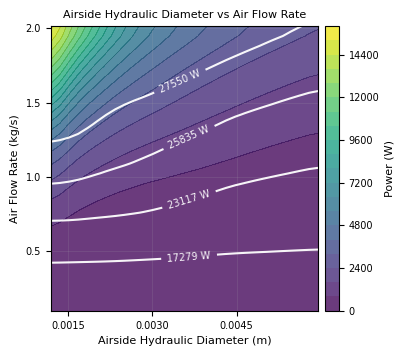


2. Frontal Area vs HX Overall Length
Generating dependency-safe POWER heatmap: HX overall length (m) vs frontal_area
Saved plot as new/hx3_power_heatmap_HX_overall_length_m_vs_frontal_area.png


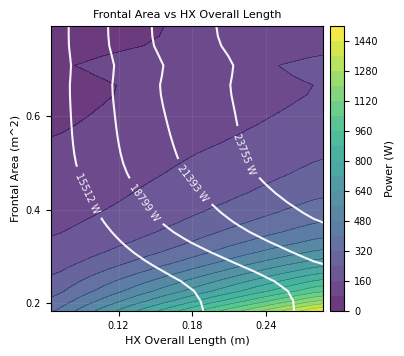


3. Porosity vs Strut Diameter
Generating dependency-safe POWER heatmap: porosity vs Strut Diameter (m)
Saved plot as new/hx3_power_heatmap_porosity_vs_Strut_Diameter_m.png


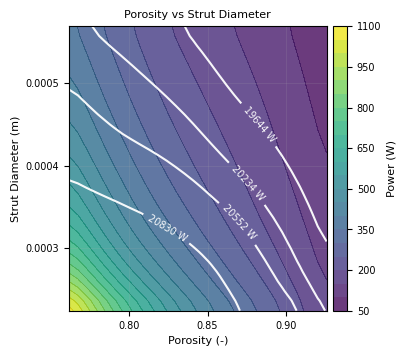


HX3 HEATMAP GENERATION COMPLETE

Generated 3 heatmaps showing:
  - Power consumption (color intensity)
  - Iso-heat-load contours (white lines)
  - Dependency-safe sweeping for derived features

Coverage and projection summary:
  1) AS Hydraulic Diameter vs Air Flow Rate: 100.0% | projected points: 0
  2) Frontal Area vs HX Overall Length: 100.0% | projected points: 0
  3) Porosity vs Strut Diameter: 100.0% | projected points: 0


In [56]:
# ============================================================================
# Generate HX3 Heatmaps with Dependency-safe Derived Feature Sweeping
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING HX3 POWER HEATMAPS")
print("=" * 80)

# Use projected mode for near-full coverage with minimum-distortion fallback
solve_mode = 'projected'
projection_reg = 0.2
projection_rel_scale = 0.05

# Heatmap 1: Airside Hydraulic Diameter vs Air Flow Rate
print("\n1. AS Hydraulic Diameter vs Air Flow Rate")
result1 = create_robust_2d_heatmap(
    best_result,
    feature_1_name='AS_hyd_diam',
    feature_2_name='Air flow rate (kg/s)',
    grid_size=30,
    percentile_range=(9, 95),
    save_plot=True,
    plot_title='Airside Hydraulic Diameter vs Air Flow Rate',
    xtitle='Airside Hydraulic Diameter (m)',
    ytitle='Air Flow Rate (kg/s)',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# Heatmap 2: HX Frontal Area vs HX Overall Length
print("\n2. Frontal Area vs HX Overall Length")
result2 = create_robust_2d_heatmap(
    best_result,
    feature_2_name='frontal_area',
    feature_1_name='HX overall length (m)',
    grid_size=30,
    percentile_range=(9, 95),
    save_plot=True,
    plot_title='Frontal Area vs HX Overall Length',
    ytitle='Frontal Area (m^2)',
    xtitle='HX Overall Length (m)',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

# Heatmap 3: Porosity vs Strut Diameter
print("\n3. Porosity vs Strut Diameter")
result3 = create_robust_2d_heatmap(
    best_result,
    feature_1_name='porosity',
    feature_2_name='Strut Diameter (m)',
    grid_size=30,
    percentile_range=(9, 95),
    save_plot=True,
    plot_title='Porosity vs Strut Diameter',
    xtitle='Porosity (-)',
    ytitle='Strut Diameter (m)',
    solve_mode=solve_mode,
    projection_reg=projection_reg,
    projection_rel_scale=projection_rel_scale,
)

print("\n" + "=" * 80)
print("HX3 HEATMAP GENERATION COMPLETE")
print("=" * 80)
print("\nGenerated 3 heatmaps showing:")
print("  - Power consumption (color intensity)")
print("  - Iso-heat-load contours (white lines)")
print("  - Dependency-safe sweeping for derived features")
print("\nCoverage and projection summary:")
print(f"  1) AS Hydraulic Diameter vs Air Flow Rate: {result1['coverage_percentage']:.1f}% | projected points: {result1['projected_points']}")
print(f"  2) Frontal Area vs HX Overall Length: {result2['coverage_percentage']:.1f}% | projected points: {result2['projected_points']}")
print(f"  3) Porosity vs Strut Diameter: {result3['coverage_percentage']:.1f}% | projected points: {result3['projected_points']}")